### Figure paper threshold search 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

clin = pd.read_csv('/Users/smasarone/Desktop/Atom_Trauma/Trauma_ML/XGB_grid_search/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Desktop/Trauma_data_scripts/data_final/dataset_final_4979prot.csv',
                   header = 0, index_col = 0)
clin = clin.drop(labels = 1578, axis = 0)
print("prot shape", prot.shape)
print("clin shape", clin.shape)

# scale 
X = StandardScaler().fit_transform(prot)
df_scaled = pd.DataFrame(X)
df_scaled.columns = prot.columns
df_scaled.index = prot.index

df_scaled.to_csv('/Users/smasarone/Documents/dataset_4979_scaled.csv')

prot shape (414, 4979)
clin shape (414, 38)


best train res 0.995712
eval: [0.875706, 0.879773, 0.87976, 0.893194, 0.895349, 0.879838, 0.873682, 0.896659, 0.884421, 0.910066, 0.905727, 0.893805] [38, 39, 47, 17, 13, 17, 16, 60, 33, 47, 35, 38]


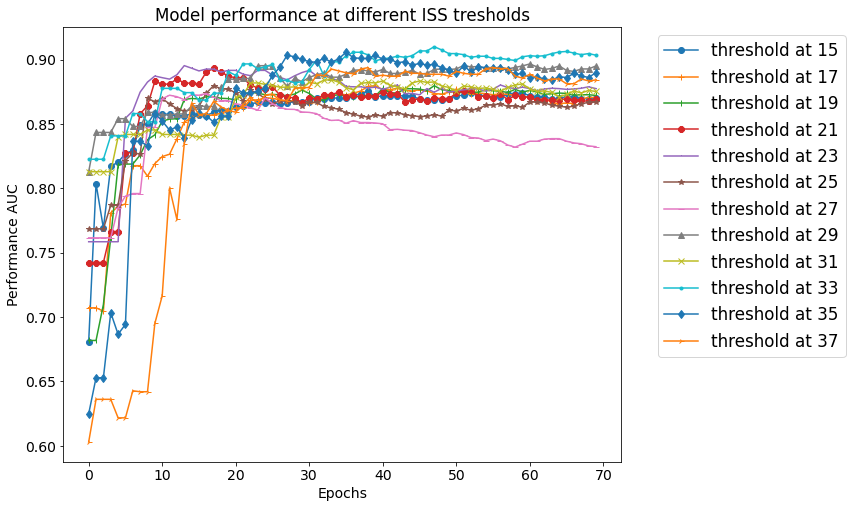

In [4]:
#define groups for model
import xgboost as xgb
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
import itertools

res = []
iterations= []
iterations_ = []
models = []
score = []
labels_ =[]
min_thr=15
max_thr=39 #35
step=2

for n in range(min_thr, max_thr, step):
    labels_.append("threshold at "+ str(n))
    target = []
    for i in clin['iss']:
        if i > n:
            target.append(1)
        else:
            target.append(0)
    
    y = target
    
    #split train and test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size = 0.3, random_state = 32)        
            
    dtrain = xgb.DMatrix(X_train, label= y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    param = {'max_depth': 1, 'eta': 0.1, 'objective': 'binary:logistic'}
    param['nthread'] = -1
    param['eval_metric'] = 'auc'
    num_round = 70
    evallist = [(dtest, 'eval'), (dtrain, 'train')]
    progress = {}
    bst = xgb.train(param, dtrain, num_round, evallist, evals_result = progress, verbose_eval=0, early_stopping_rounds=15) 
    
    models.append(bst)
    
    #check if training goes to 1 
    position_ = np.argmax(progress['train']['auc'])
    iterations_.append(position_)
    best_res_ = progress['train']['auc'][position_] #check if there's a 1

    #save best result at best iteration
    position = np.argmax(progress['eval']['auc']) #position best score
    iterations.append(position)                   #save all position of best iterations
    best_res = progress['eval']['auc'][position]  #best result
    res.append(best_res)                          #save best result
    
    #append scores
    score.append(progress['eval']['auc'][:])
    
      
score_array = np.asarray(score)
score_array = score_array.T    
fontP = FontProperties()
fontP.set_size('large')
#print(score)

markers =["o","+","|","8", ",","*","_","^","x",".","d","4"]

ax = plt.figure(figsize=(10,8))
ax = plt.xlabel("Epochs")
ax = plt.ylabel("Performance AUC")
ax = plt.rcParams.update({'font.size': 14})  #font at 23 to save


for i,z in enumerate(markers):
    
    ax = plt.plot(score_array[:,i], marker=z) 
    
plt.legend(labels=labels_, bbox_to_anchor=(1.05, 1), prop=fontP)    
plt.title("Model performance at different ISS tresholds")
plt.savefig('threshold_iss.pdf', bbox_inches = 'tight')

print("best train res", best_res_)   
print("eval:", res, iterations)

### Re-run just for the ones we have in the table

best train res 1.0
eval: [0.890244, 0.876248, 0.880952, 0.8722, 0.8722, 0.899184, 0.889666, 0.889666, 0.889666, 0.906147] [15, 11, 8, 8, 8, 22, 17, 17, 17, 23]


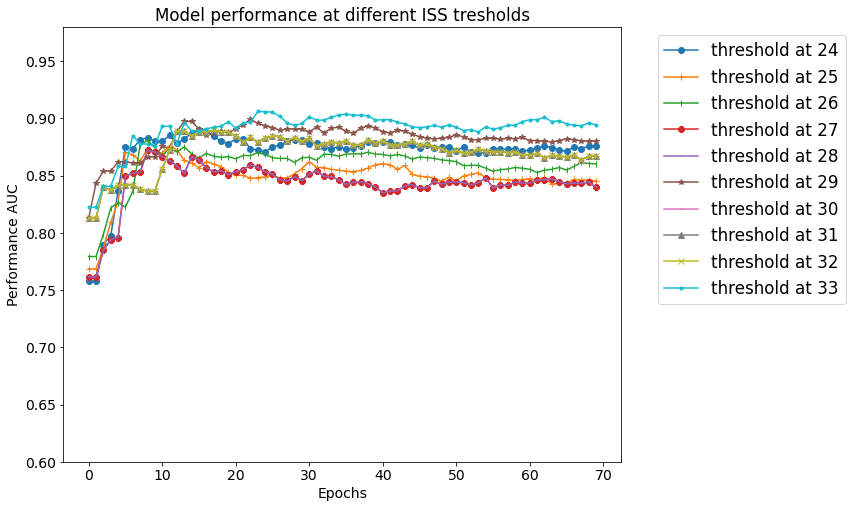

In [5]:
res = []
iterations= []
iterations_ = []
models = []
score = []
labels_ =[]
min_thr=24
max_thr=34 #35
step=1

for n in range(min_thr, max_thr, step):
    labels_.append("threshold at "+ str(n))
    target = []
    for i in clin['iss']:
        if i > n:
            target.append(1)
        else:
            target.append(0)
    
    y = target
    
    #split train and test
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(df_scaled, y, test_size = 0.3, random_state = 32)        
            
    dtrain = xgb.DMatrix(X_train, label= y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    param = {'max_depth': 1, 'eta': 0.2, 'objective': 'binary:logistic'}
    param['nthread'] = -1
    param['eval_metric'] = 'auc'
    num_round = 70
    evallist = [(dtest, 'eval'), (dtrain, 'train')]
    progress = {}
    bst = xgb.train(param, dtrain, num_round, evallist, evals_result = progress, verbose_eval=0, 
                    early_stopping_rounds=25) 
    
    models.append(bst)
    
    #check if training goes to 1 
    position_ = np.argmax(progress['train']['auc'])
    iterations_.append(position_)
    best_res_ = progress['train']['auc'][position_] #check if there's a 1

    #save best result at best iteration
    position = np.argmax(progress['eval']['auc']) #position best score
    iterations.append(position)                   #save all position of best iterations
    best_res = progress['eval']['auc'][position]  #best result
    res.append(best_res)                          #save best result
    
    #append scores
    score.append(progress['eval']['auc'][:])
    
      
score_array = np.asarray(score)
score_array = score_array.T    
fontP = FontProperties()
fontP.set_size('large')
#print(score)

markers =["o","+","|","8", ",","*","_","^","x","."]

ax = plt.figure(figsize=(10,8))
ax = plt.xlabel("Epochs")
ax = plt.ylabel("Performance AUC")
ax = plt.rcParams.update({'font.size': 14})  #font at 23 to save


for i,z in enumerate(markers):
    
    ax = plt.plot(score_array[:,i], marker=z) 
    
plt.legend(labels=labels_, bbox_to_anchor=(1.05, 1), prop=fontP)    
plt.title("Model performance at different ISS tresholds")
plt.ylim(0.6, 0.98)
plt.savefig('threshold_iss.pdf', bbox_inches = 'tight')


print("best train res", best_res_)   
print("eval:", res, iterations)

In [6]:
###if you change the depth also have to change the epochs otherwise with erly stopping it will stop before 70 and throw an error  

In [7]:
#there are about 60 patients that fall in this group and they seem to be more separable than the others

counter  = 0
for i in clin['iss']:
    if i > 33: #33 is ideal
        counter = counter+1
    else:
        pass
print(counter)
print(len(clin)-counter)

60
354


In [11]:
threshold_=[]
n_patients=[]
for threshold in range(24, 34, 1):
    threshold_.append(threshold)
    counter=0
    for value in clin['iss']:
        if value > threshold: #33 is ideal
            counter+=1
        else:
            continue
    n_patients.append(counter)
    print(threshold, counter)
    

24 108
25 94
26 92
27 86
28 86
29 66
30 64
31 64
32 64
33 60


In [9]:
# make a table
threshold_table = pd.DataFrame(threshold_, columns=['Threshold'])
threshold_table['N. of critical patients'] = n_patients

threshold_table

,Threshold,N. of critical patients
0,24,108
1,25,94
2,26,92
3,27,86
4,28,86
5,29,66
6,30,64
7,31,64
8,32,64
9,33,60


In [10]:
# table of patients
threshold_table["N. of non critical patients"] = 414 - threshold_table['N. of critical patients']
threshold_table 

,Threshold,N. of critical patients,N. of non critical patients
0,24,108,306
1,25,94,320
2,26,92,322
3,27,86,328
4,28,86,328
5,29,66,348
6,30,64,350
7,31,64,350
8,32,64,350
9,33,60,354
